# Breast Cancer Wisconsin Classification

## 1. Problem definition

Can a logistic regression pipeline classify held-out samples as malignant or benign more effectively than a trivial baseline?

## 2. Imports and reproducibility

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn import set_config

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Dataset loading

In [3]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# Scikit-learn originally encodes malignant as 0 and benign as 1.
# Remap the target so malignant is the positive class used by binary metrics.
df['target'] = df['target'].map({0: 1, 1: 0})

## 4. Dataset inspection

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='str')

In [7]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [8]:
df.select_dtypes(include='int64').columns

Index(['target'], dtype='str')

In [9]:
df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [10]:
df.target.value_counts()

target
0    357
1    212
Name: count, dtype: int64

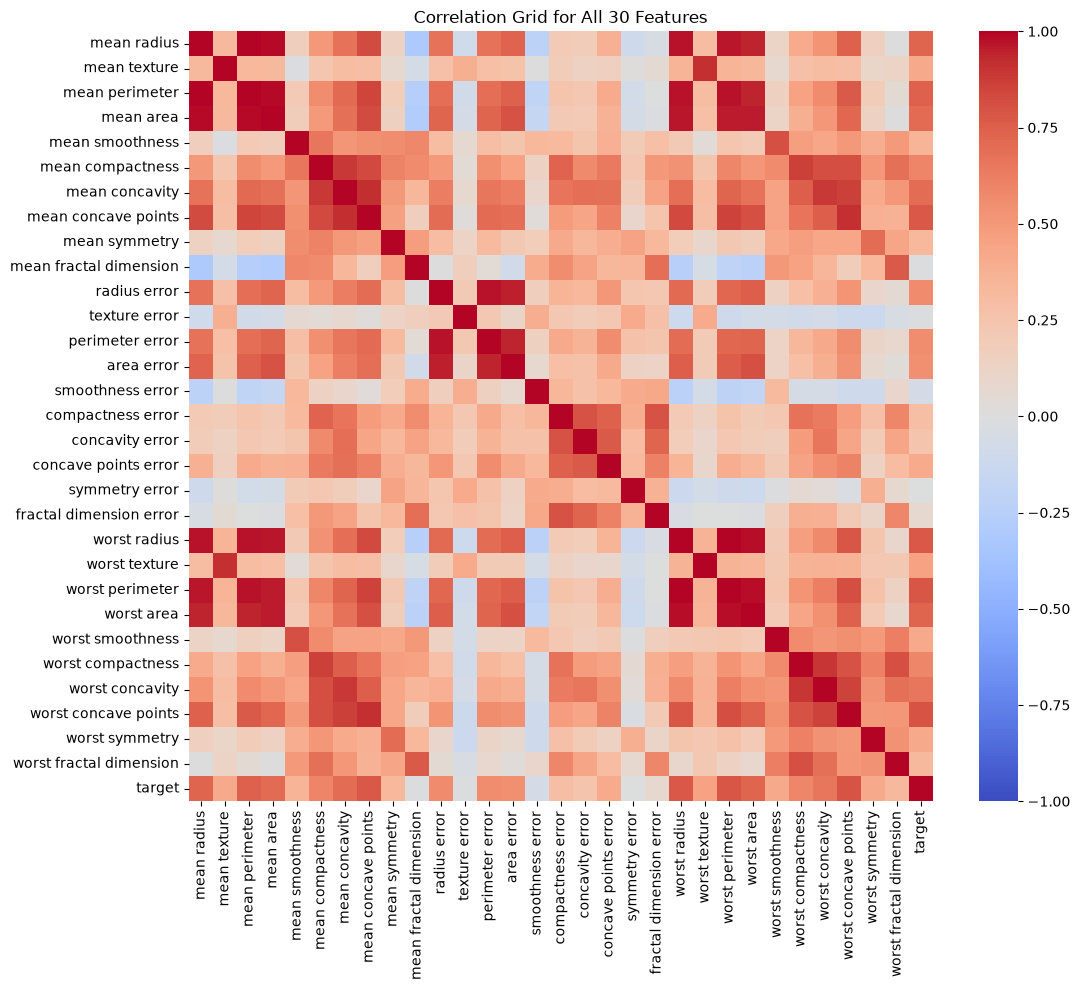

In [11]:
# 1. Calculate the correlation numbers for all columns
correlation_matrix = df.corr()

# 2. Plot it as a heatmap (grid of colors)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Grid for All 30 Features")
plt.show()

In [12]:
duplicate_columns = ['mean radius', 'mean perimeter', 'radius error', 'perimeter error', 'worst radius', 'worst perimeter']

df_cleaned = df.drop(columns=duplicate_columns)

df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean texture             569 non-null    float64
 1   mean area                569 non-null    float64
 2   mean smoothness          569 non-null    float64
 3   mean compactness         569 non-null    float64
 4   mean concavity           569 non-null    float64
 5   mean concave points      569 non-null    float64
 6   mean symmetry            569 non-null    float64
 7   mean fractal dimension   569 non-null    float64
 8   texture error            569 non-null    float64
 9   area error               569 non-null    float64
 10  smoothness error         569 non-null    float64
 11  compactness error        569 non-null    float64
 12  concavity error          569 non-null    float64
 13  concave points error     569 non-null    float64
 14  symmetry error           569 non-null

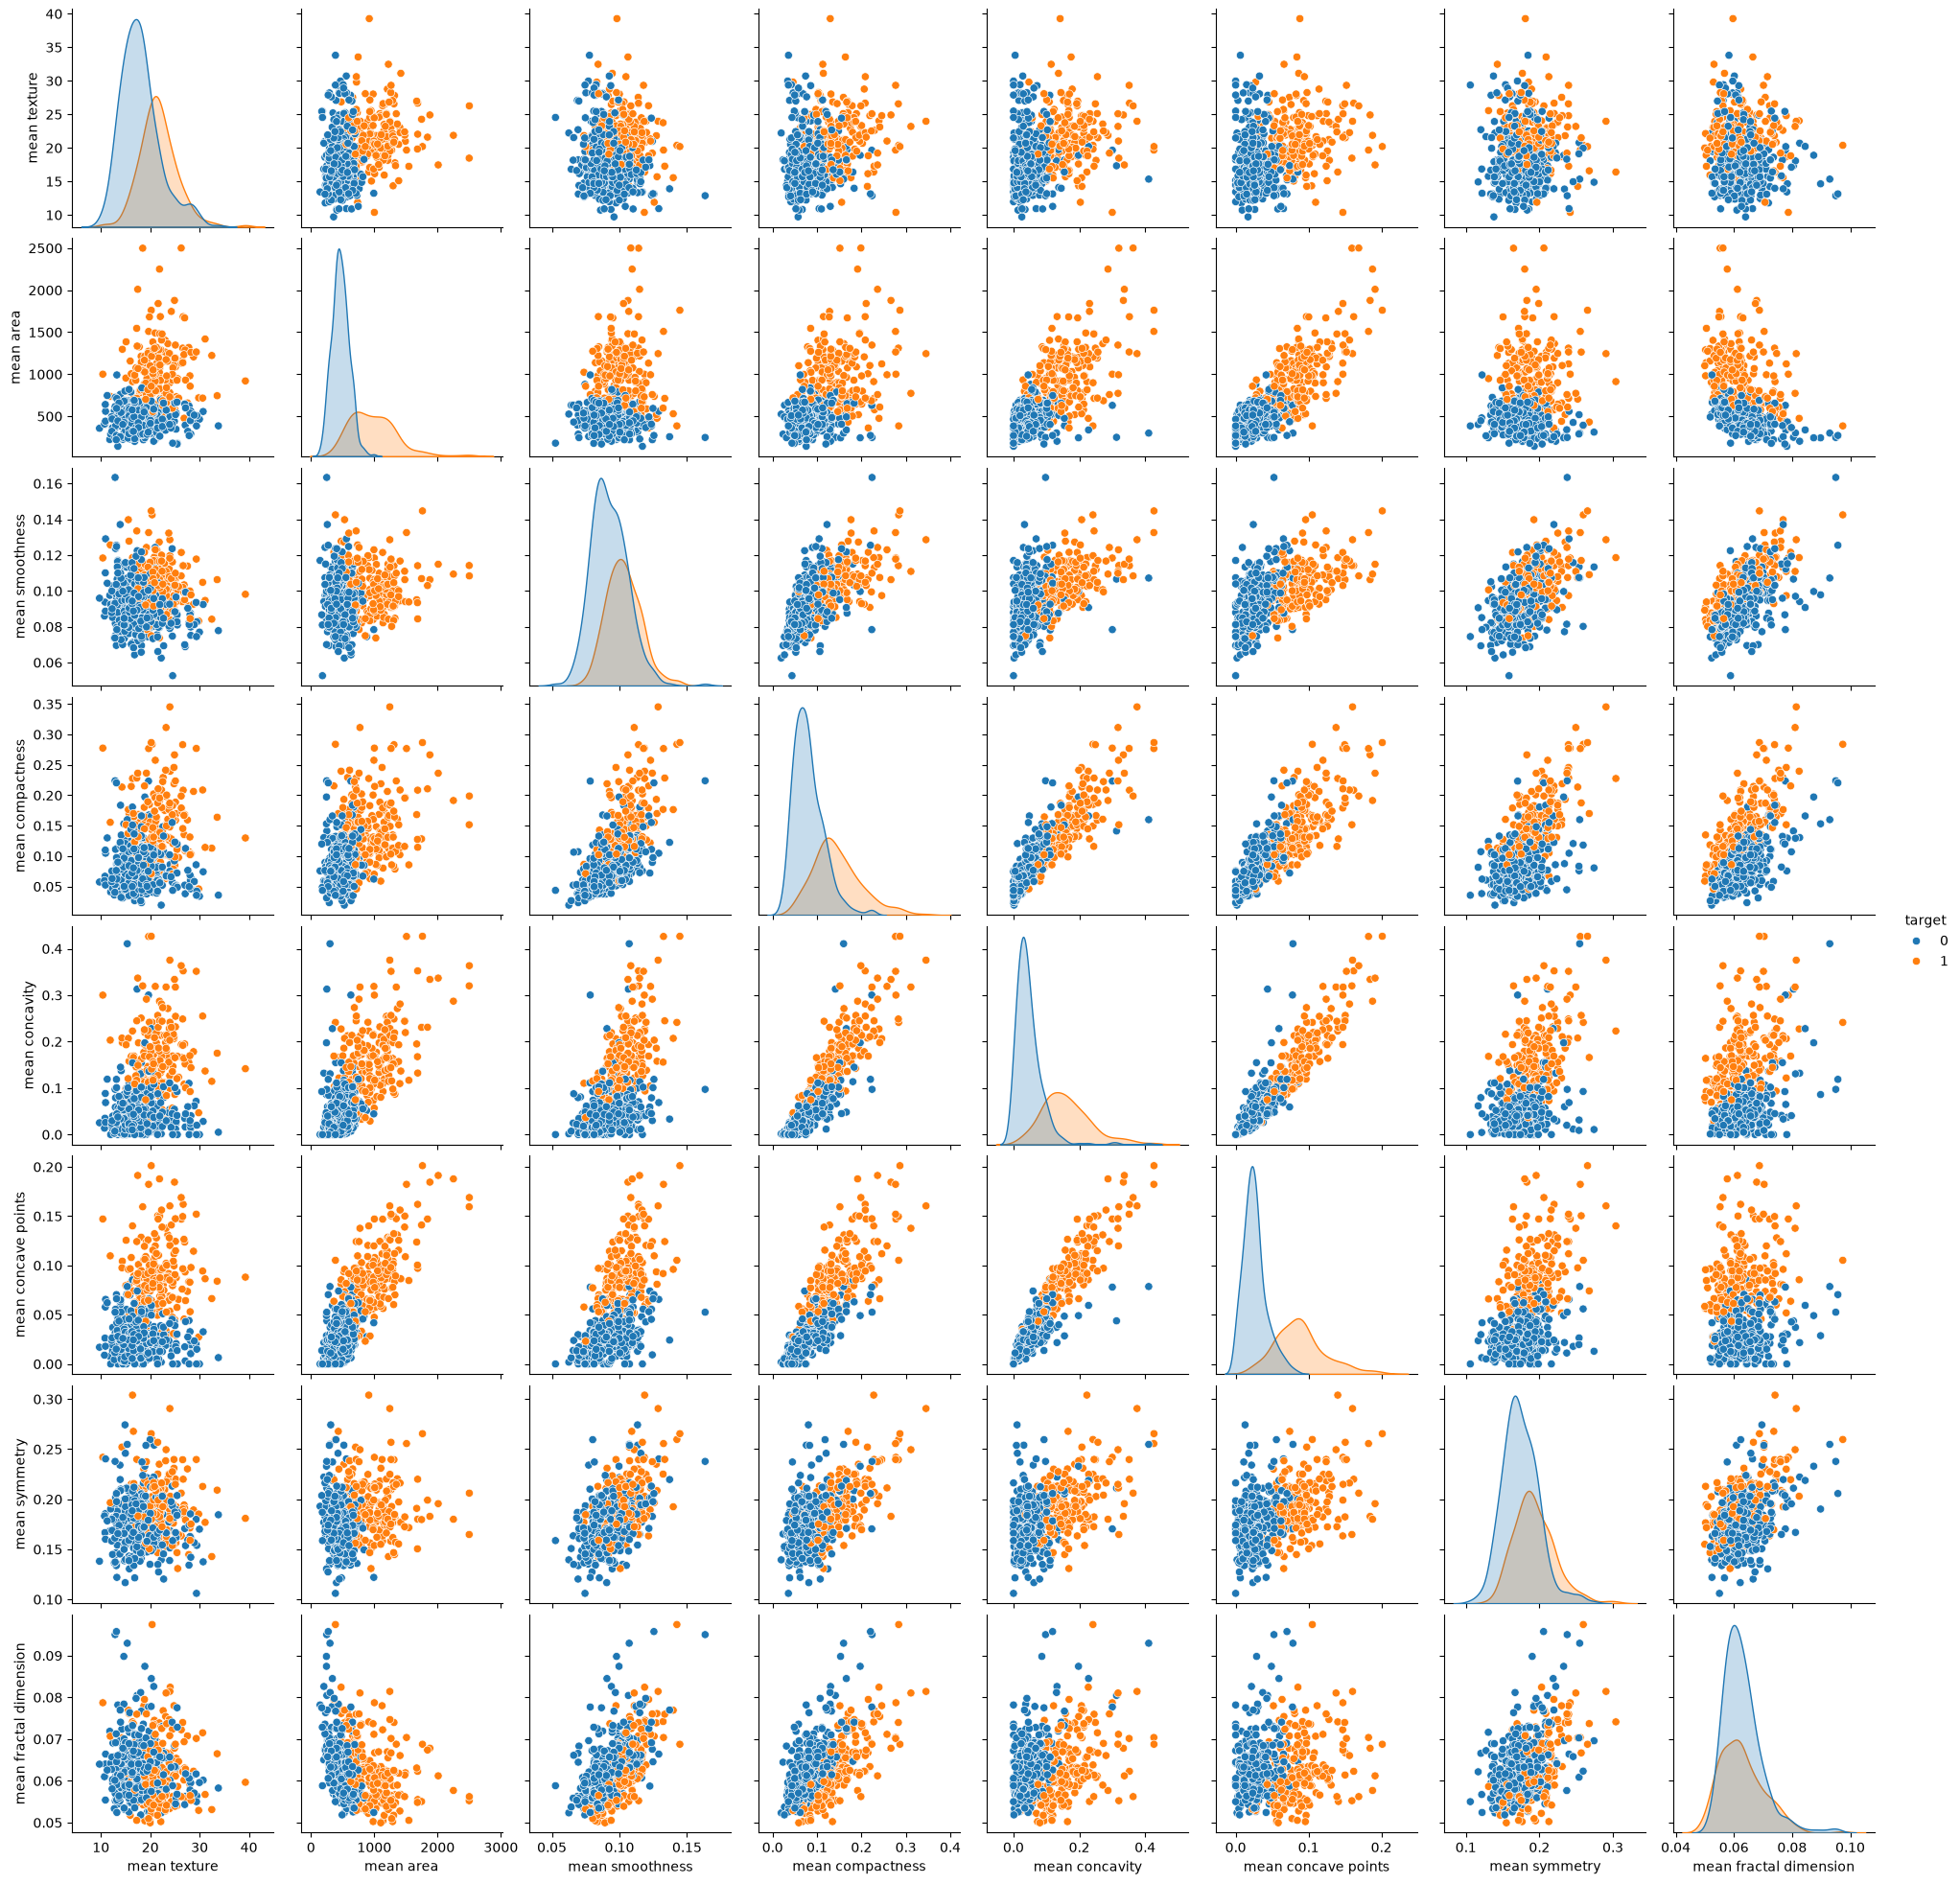

In [13]:
mean_features = [col for col in df_cleaned.columns if 'mean' in col] + ['target']
error_features = [col for col in df_cleaned.columns if 'error' in col] + ['target']
worst_features = [col for col in df_cleaned.columns if 'worst' in col] + ['target']

sns.pairplot(df_cleaned[mean_features], hue='target')

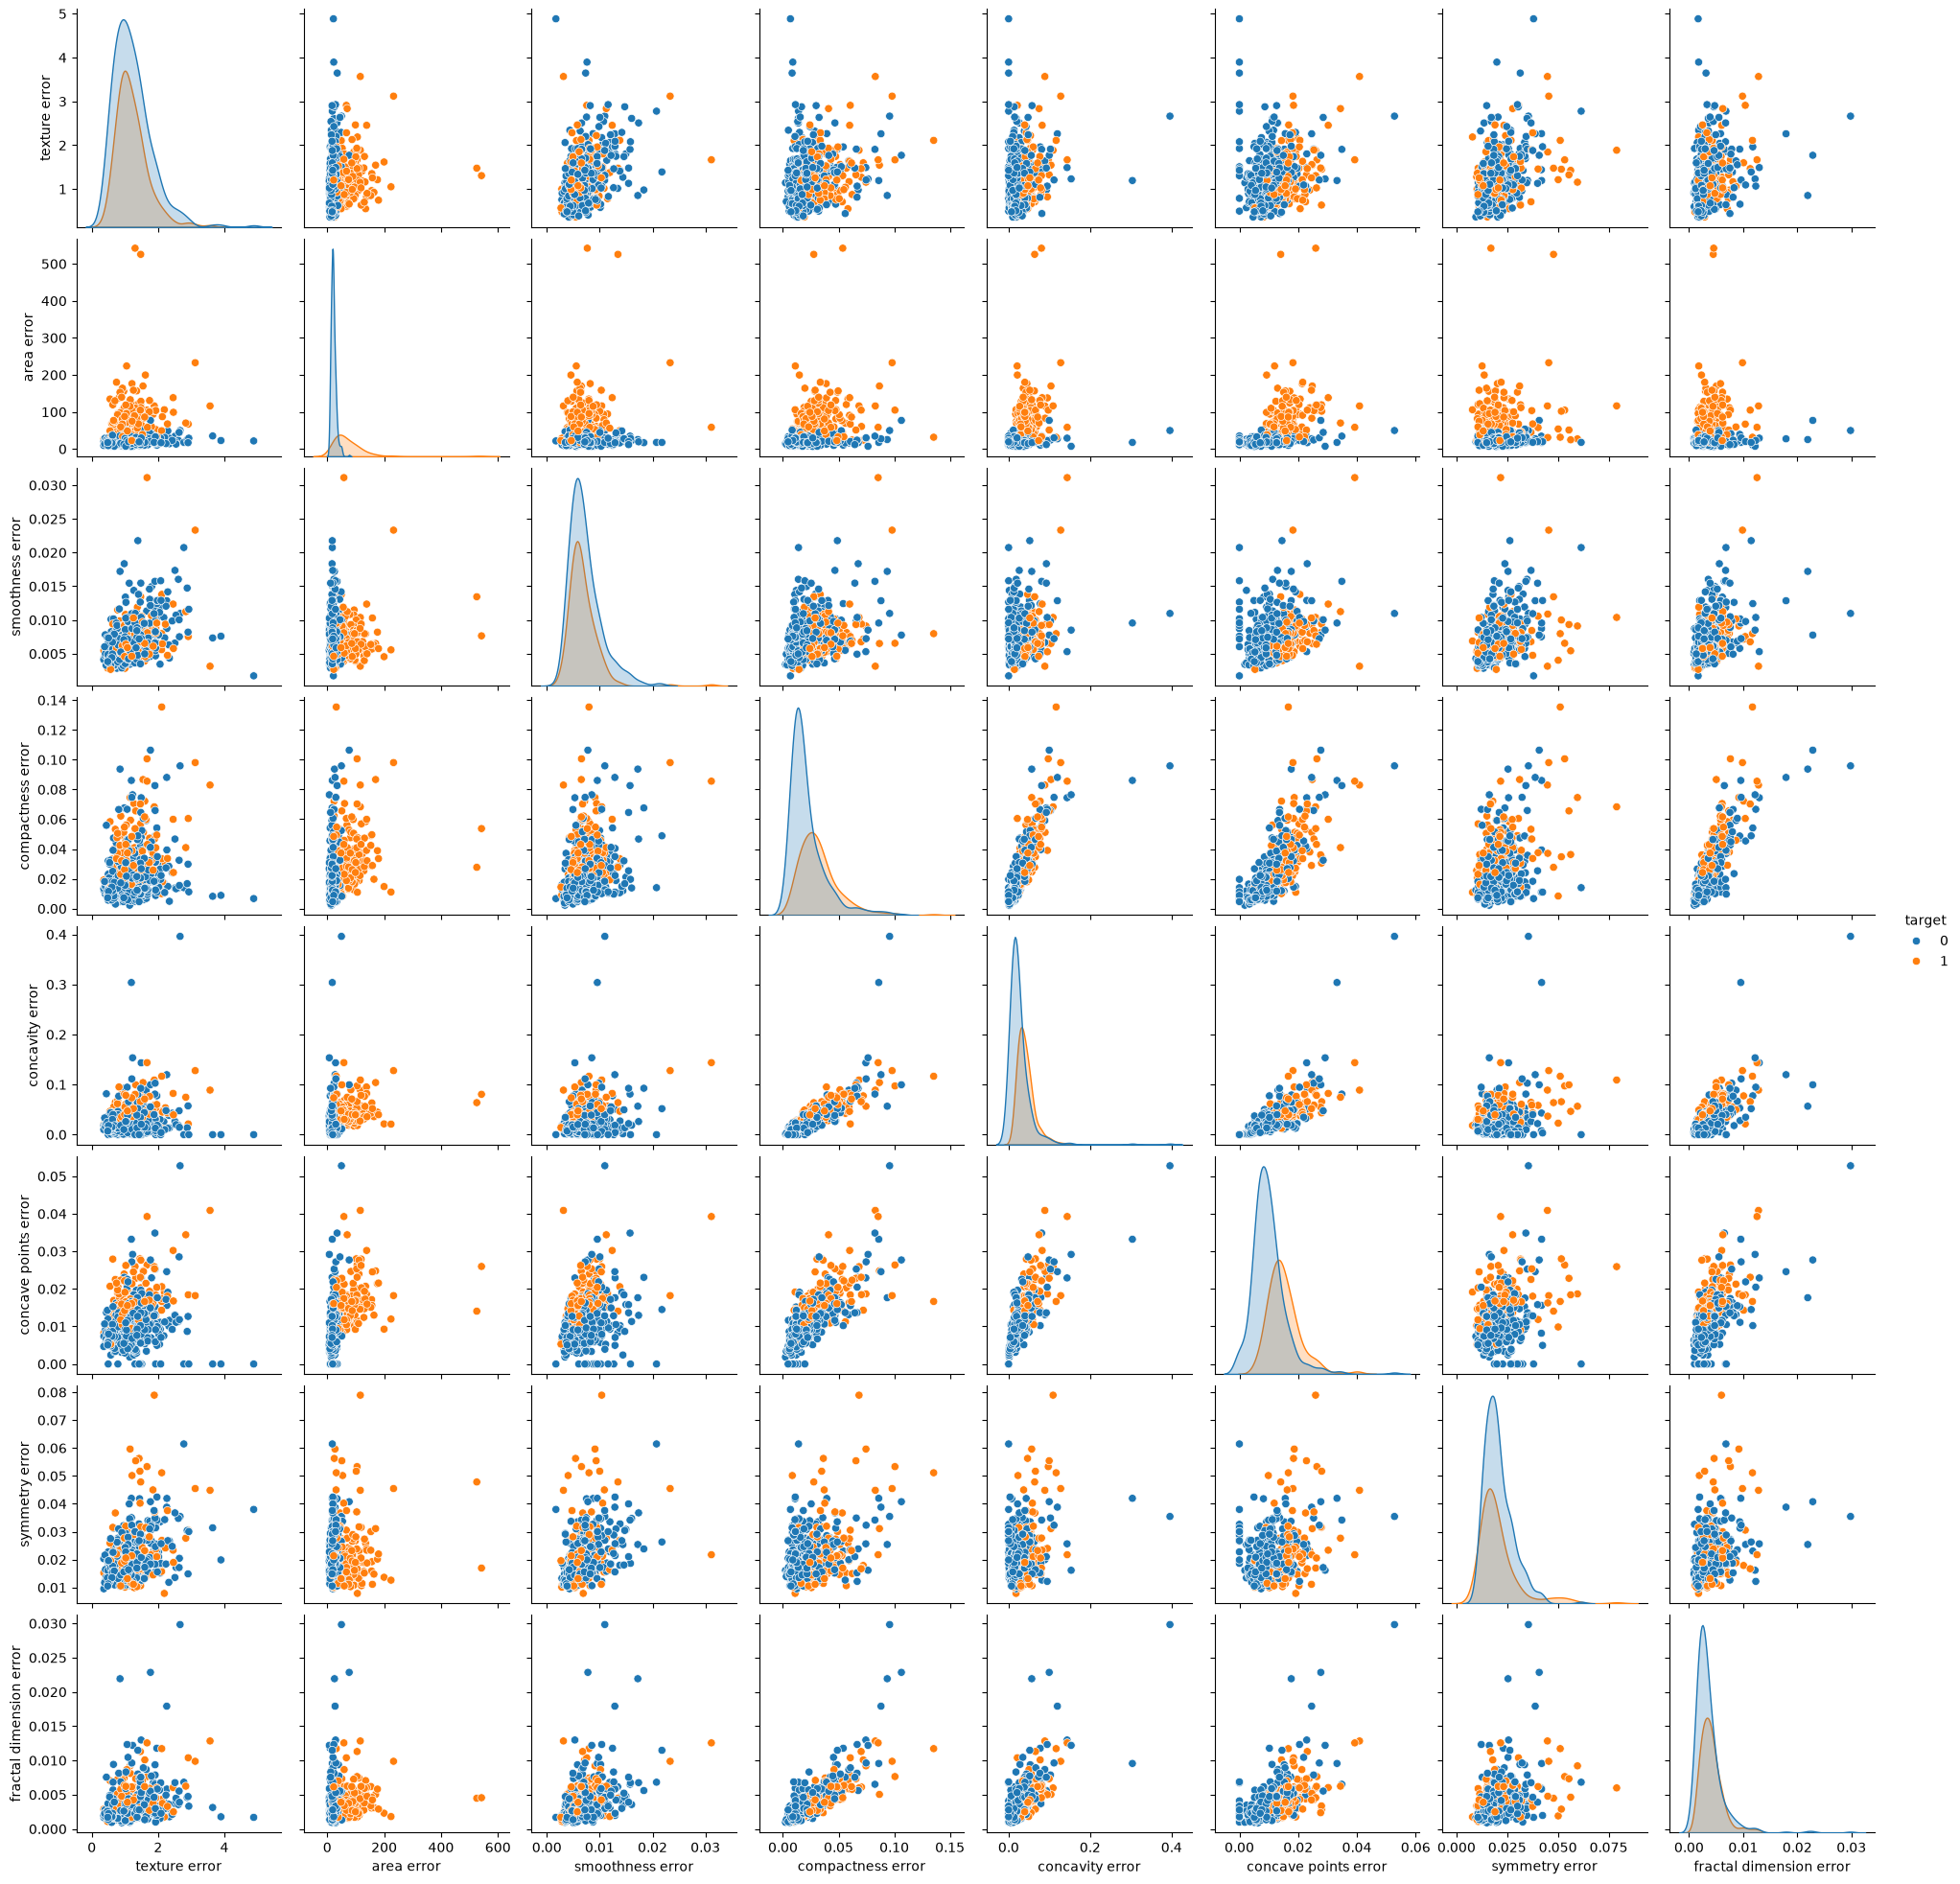

In [14]:
sns.pairplot(df_cleaned[error_features], hue='target')

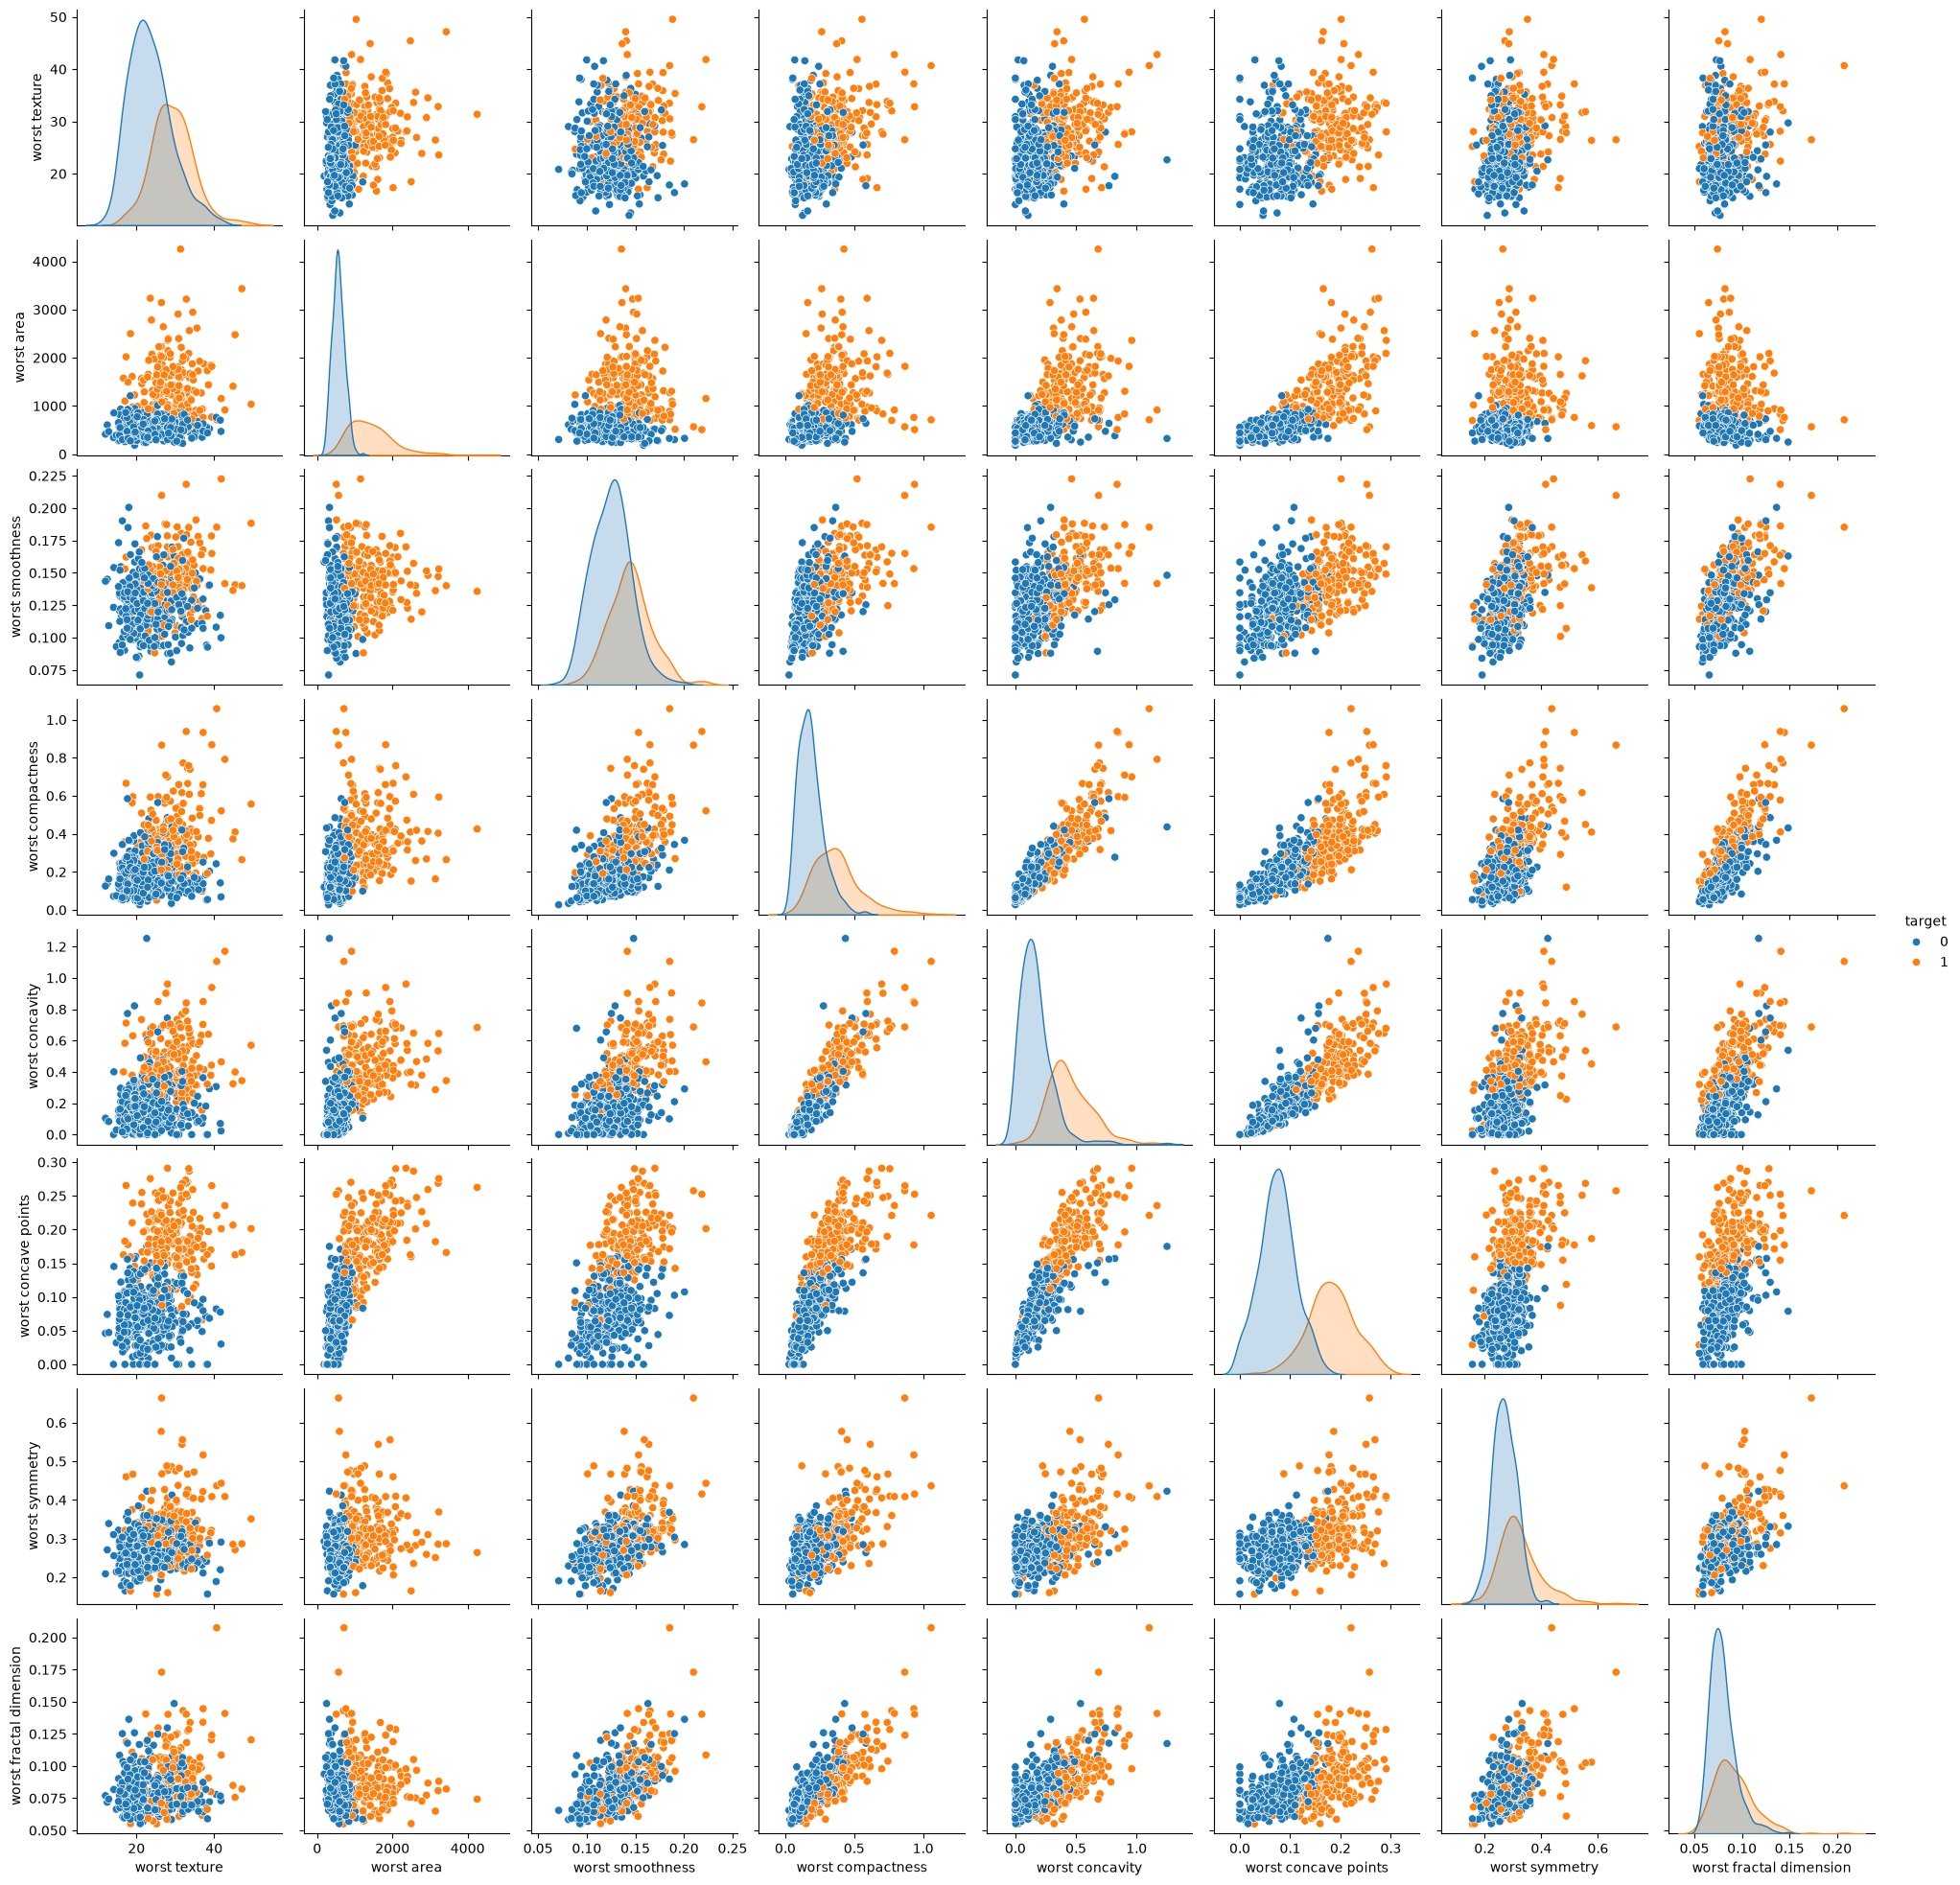

In [15]:
sns.pairplot(df_cleaned[worst_features], hue='target')

Summary:

- **Dataset scale:** There are 569 total samples and 31 columns: 30 features and 1 target variable.
- **Data types:** All features are continuous numerical measurements of cell nuclei. The target is binary, with **0 representing benign** and **1 representing malignant**.
- **Target balance:** The dataset contains 357 benign samples and 212 malignant samples.
- **Data quality:** There are no missing values.
- **Feature structure:** The 30 features are derived from 10 physical measurements, each represented by its mean, standard error and worst value.
- **Multicollinearity review:** The correlation heatmap showed very strong relationships between radius, perimeter and area measurements. Six radius and perimeter columns were removed while retaining the corresponding area measurements.
- **Visual inspection:** The pair plots show substantial separation between the classes across several features, supporting logistic regression as a reasonable linear classification model for this workflow.

## 5. Features and target

In [16]:
X = df_cleaned.drop(columns='target')
y = df_cleaned.target

## 6. Preprocessing

In [17]:
set_config(display='diagram')

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_scaler', StandardScaler(), X.columns)
    ]
)

The numerical features are scaled so that measurements with larger numerical ranges do not dominate the logistic regression model.

Keeping the scaler inside the pipeline also ensures that scaling parameters are learned from the training data and then applied consistently to validation and test data.

## 7. Train/test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

The split is stratified using the target so that the training and test sets retain approximately the same proportions of benign and malignant samples as the full dataset.

## 8. Baseline model

In [19]:
dummy_pipeline = Pipeline(
    steps=[
        ("dummy_classifier", DummyClassifier(strategy="most_frequent"))
    ]
)

dummy_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dummy_classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['mean texture','mean area','mean smoothness',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_s

In [20]:
dummy_predictions = dummy_pipeline.predict(X_test)

## 9. Logistic regression pipeline

In [23]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("logistic_regression", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print("=== Logistic Regression 5-Fold Cross-Validation ===")
print(f"CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"CV Precision (malignant): {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"CV Recall (malignant):    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"CV F1 Score (malignant):  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

=== Logistic Regression 5-Fold Cross-Validation ===
CV Accuracy:  0.9714 ± 0.0204
CV Precision (malignant): 0.9822 ± 0.0241
CV Recall (malignant):    0.9412 ± 0.0492
CV F1 Score (malignant):  0.9604 ± 0.0283


## 10. Model training and predictions

In [ ]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['mean texture','mean area','mean smoothness',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

In [ ]:
model_predictions = model_pipeline.predict(X_test)

## 11. Model evaluation

In [ ]:
# Malignant is encoded as 1, so it is the positive class for these metrics.
model_accuracy = accuracy_score(y_test, model_predictions)
model_precision = precision_score(y_test, model_predictions, pos_label=1)
model_recall = recall_score(y_test, model_predictions, pos_label=1)
model_f1 = f1_score(y_test, model_predictions, pos_label=1)

# Rows are actual classes and columns are predicted classes.
# The default class order is [0, 1] = [benign, malignant].
matrix = confusion_matrix(y_test, model_predictions)

In [ ]:
print("=== Logistic Regression Test Metrics ===")
print(f"Accuracy:  {model_accuracy:.4f}")
print(f"Precision (malignant): {model_precision:.4f}")
print(f"Recall (malignant):    {model_recall:.4f}")
print(f"F1 Score (malignant):  {model_f1:.4f}")

=== Logistic Regression Test Metrics ===
Accuracy:  0.9737
Precision (malignant): 1.0000
Recall (malignant):    0.9286
F1 Score (malignant):  0.9630


## 12. Baseline comparison

In [ ]:
dummy_accuracy = accuracy_score(y_test, dummy_predictions)
dummy_precision = precision_score(y_test, dummy_predictions, pos_label=1, zero_division=0)
dummy_recall = recall_score(y_test, dummy_predictions, pos_label=1, zero_division=0)
dummy_f1 = f1_score(y_test, dummy_predictions, pos_label=1, zero_division=0)

dummy_matrix = confusion_matrix(y_test, dummy_predictions)

comparison = pd.DataFrame(
    {
        'Accuracy': [dummy_accuracy, model_accuracy],
        'Precision (malignant)': [dummy_precision, model_precision],
        'Recall (malignant)': [dummy_recall, model_recall],
        'F1 (malignant)': [dummy_f1, model_f1]
    },
    index=['Dummy baseline', 'Logistic regression']
)

comparison

,Accuracy,Precision (malignant),Recall (malignant),F1 (malignant)
Dummy baseline,0.631579,0.0,0.000000,0.000000
Logistic regression,0.973684,1.0,0.928571,0.962963


The dummy baseline predicts the majority class for every sample. Because the majority class is benign (`0`), it achieves an accuracy of approximately 63%, but it never predicts the malignant positive class (`1`). Its malignant precision, recall and F1 score are therefore all 0.

The logistic regression pipeline substantially outperforms this baseline. This demonstrates that its predictions use information from the input features rather than simply reproducing the majority class.

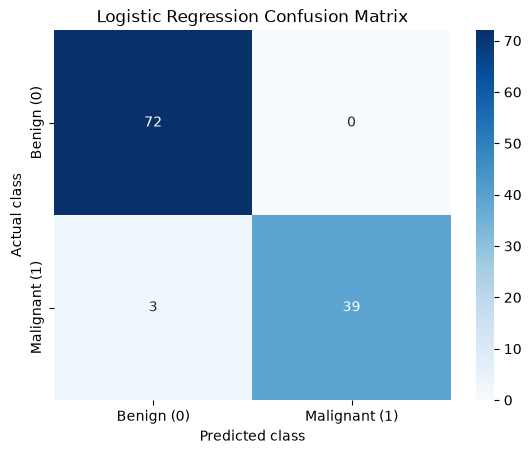

In [ ]:
sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign (0)', 'Malignant (1)'],
    yticklabels=['Benign (0)', 'Malignant (1)']
)

plt.ylabel('Actual class')
plt.xlabel('Predicted class')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

The confusion matrix uses **rows for the actual class** and **columns for the predicted class**:

- **72 true negatives:** 72 benign samples were correctly predicted as benign.
- **0 false positives:** No benign samples were incorrectly predicted as malignant.
- **3 false negatives:** Three malignant samples were incorrectly predicted as benign.
- **39 true positives:** 39 malignant samples were correctly predicted as malignant.

The three false negatives explain why malignant recall is lower than malignant precision. The model made no false-positive malignant predictions, but it missed three malignant samples.

## 13. Error analysis

In [ ]:
# Extract the fitted logistic regression coefficients.
# Because the inputs were standardised, their absolute values can be compared
# as an introductory view of which features most strongly influenced the model.
coefficient_scores = model_pipeline.named_steps['logistic_regression'].coef_[0]

coefficient_df = pd.DataFrame({
    'Feature_Name': X_train.columns,
    'Coefficient': coefficient_scores
})

coefficient_df['Absolute_Coefficient'] = coefficient_df['Coefficient'].abs()
coefficient_df.sort_values(by='Absolute_Coefficient', ascending=False).head(5)

,Feature_Name,Coefficient,Absolute_Coefficient
9,area error,2.246372,2.246372
17,worst area,1.743080,1.743080
5,mean concave points,1.216102,1.216102
1,mean area,1.193479,1.193479
16,worst texture,1.094022,1.094022


In [ ]:
# Compare the five features with the largest absolute coefficients.
top_features = ['area error', 'worst area', 'mean concave points', 'mean area', 'worst texture']

X_test.assign(target=y_test).groupby('target')[top_features].mean().T

target,0,1
area error,20.277028,64.520476
worst area,547.369444,1343.623810
mean concave points,0.027512,0.084582
mean area,458.568056,940.640476
worst texture,22.719306,28.281667


In [ ]:
predictions_series = pd.Series(model_predictions, index=y_test.index)

mistake_mask = y_test != predictions_series

error_analysis_table = X_test[mistake_mask].copy()

error_analysis_table['True_Label'] = y_test[mistake_mask]
error_analysis_table['Prediction'] = predictions_series[mistake_mask]

error_analysis_table

,mean texture,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,texture error,area error,...,worst texture,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,True_Label,Prediction
73,15.79,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,0.6205,23.35,...,20.86,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.1030,1,0
190,23.12,609.9,0.10750,0.24130,0.19810,0.06618,0.2384,0.07542,2.1100,31.72,...,37.18,762.4,0.1533,0.9327,0.8488,0.1772,0.5166,0.1446,1,0
205,16.68,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,0.3621,26.44,...,20.24,989.5,0.1491,0.3331,0.3327,0.1252,0.3415,0.0974,1,0


The model made three classification errors, and all three were **false negatives**: malignant samples predicted as benign.

Rows 73, 190 and 205 had several measurements below the malignant test-set averages and closer to the benign averages, particularly for area-related features. This provides a plausible descriptive explanation for why these cases fell on the benign side of the model's linear decision boundary.

This small error review does not establish that any single feature caused the mistakes. It only shows how the misclassified samples differed from the average feature patterns observed in the test set.

## 14. Controlled extension

Implementation:

- 14.1 Learning curve
- 14.2 Limited regularisation tuning
- 14.3 Default vs tuned validation comparison
- 14.4 Extension interpretation

## 14.1 Learning curve

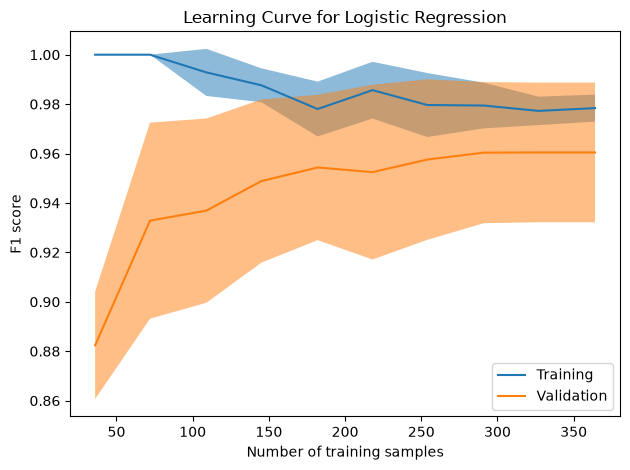

(array([ 36,  72, 109, 145, 182, 218, 254, 291, 327, 364]),
 array([[1.        , 1.        , 1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        , 1.        , 1.        ],
        [0.98795181, 0.97619048, 1.        , 1.        , 1.        ],
        [0.99130435, 0.97391304, 0.99099099, 0.99099099, 0.99099099],
        [0.97810219, 0.95652174, 0.98529412, 0.98507463, 0.98507463],
        [0.98823529, 0.96470588, 1.        , 0.98765432, 0.98765432],
        [0.99      , 0.97      , 1.        , 0.96907216, 0.96907216],
        [0.98214286, 0.96888889, 0.99559471, 0.97777778, 0.97272727],
        [0.98823529, 0.97254902, 0.9765625 , 0.97254902, 0.97637795],
        [0.98507463, 0.9739777 , 0.98127341, 0.97014925, 0.98141264]]),
 array([[0.8852459 , 0.91666667, 0.85714286, 0.89189189, 0.86111111],
        [0.9375    , 0.97058824, 0.94117647, 0.95774648, 0.85714286],
        [0.95384615, 0.95652174, 0.90625   , 0.98550725, 0.88235294],
        [0.96969697, 0.94285

In [57]:
from sklearn.model_selection import LearningCurveDisplay, learning_curve
import numpy as np

display = LearningCurveDisplay.from_estimator(
    model_pipeline,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='f1', # Use F1 because it balances precision and recall
)

display.ax_.set_title("Learning Curve for Logistic Regression")
display.ax_.set_xlabel("Number of training samples")
display.ax_.set_ylabel("F1 score")

handles, labels = display.ax_.get_legend_handles_labels()
labels = [
    label.replace("Train", "Training").replace("Test", "Validation")
    for label in labels
]
display.ax_.legend(handles, labels)

plt.tight_layout()
plt.savefig("learning_curve.png")
plt.show()

learning_curve_results = learning_curve(
    model_pipeline,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='f1'
)

learning_curve_results

In [25]:
train_sizes, train_scores, validation_scores = learning_curve_results

learning_curve_summary = pd.DataFrame({
    "train_size": train_sizes,
    "train_f1_mean": train_scores.mean(axis=1), # axis=1 means averaging across the 5 folds for each training size
    "train_f1_std": train_scores.std(axis=1),
    "validation_f1_mean": validation_scores.mean(axis=1),
    "validation_f1_std": validation_scores.std(axis=1),
})

learning_curve_summary.round(4)

,train_size,train_f1_mean,train_f1_std,validation_f1_mean,validation_f1_std
0,36,1.0000,0.0000,0.8824,0.0217
1,72,1.0000,0.0000,0.9328,0.0397
2,109,0.9928,0.0095,0.9369,0.0373
3,145,0.9876,0.0069,0.9488,0.0330
4,182,0.9780,0.0111,0.9544,0.0294
5,218,0.9856,0.0115,0.9525,0.0354
6,254,0.9796,0.0129,0.9576,0.0325
7,291,0.9794,0.0092,0.9604,0.0286
8,327,0.9773,0.0058,0.9604,0.0283
9,364,0.9784,0.0055,0.9604,0.0283


At small sample sizes
- training F1 ≈ 1.0
- validation much lower
- high variance / overfitting

As sample size increases
- training score falls slightly
- validation score improves
- gap narrows

Largest sample sizes
- train ≈ 0.978
- validation ≈ 0.960
-  small gap
- both curves flatten

Conclusion
- good generalisation
- no strong underfitting
- little remaining overfitting
- additional data likely gives diminishing returns

As the training set increased, mean training F1 decreased from near-perfect performance on the smallest subsets to approximately 0.98, while mean validation F1 improved from approximately 0.88 to 0.96. The train-validation gap therefore narrowed substantially, indicating that the strong overfitting observed with very small training subsets diminished as more data became available. At the largest sample sizes, both curves were high and relatively close, providing little evidence of substantial underfitting or overfitting for the full training set. Validation performance also plateaued at approximately 0.96 from around 291 training samples onward, suggesting diminishing returns from additional data for the current logistic-regression pipeline. Validation scores showed greater fold-to-fold variability than training scores, reflecting some sensitivity to the particular held-out samples

## 14.2 Limited regularisation tuning

In [32]:
from sklearn.model_selection import GridSearchCV

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

c_search = GridSearchCV(
    model_pipeline,
    param_grid={'logistic_regression__C': C_values},
    cv=5,
    scoring='f1',
)

outer_cv = cross_validate(
    c_search,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_estimator=True
)

outer_cv

{'fit_time': array([0.22874928, 0.22293019, 0.202142  , 0.32812619, 0.24231815]),
 'score_time': array([0.00455761, 0.00442195, 0.00498581, 0.00634599, 0.00457501]),
 'estimator': [GridSearchCV(cv=5,
               estimator=Pipeline(steps=[('preprocessing',
                                          ColumnTransformer(transformers=[('numeric_scaler',
                                                                           StandardScaler(),
                                                                           Index(['mean texture', 'mean area', 'mean smoothness', 'mean compactness',
         'mean concavity', 'mean concave points', 'mean symmetry',
         'mean fractal dimension', 'texture error', 'area error',
         'smoothness error', 'compactness error', 'concavity error',
         'concave points error', 'symmetry error', 'fractal dimension error',
         'worst texture', 'worst area', 'worst smoothness', 'worst compactness',
         'worst concavity', 'worst concave p

In [33]:
[estimator.best_params_ for estimator in outer_cv['estimator']]

[{'logistic_regression__C': 10},
 {'logistic_regression__C': 100},
 {'logistic_regression__C': 10},
 {'logistic_regression__C': 100},
 {'logistic_regression__C': 1}]

The C selected within the outer folds varied between 1, 10 and 100, indicating that the exact optimum was somewhat sensitive to resampling. 
However, all selected values corresponded to moderate-to-weak regularisation, suggesting that strongly regularised configurations were consistently less favourable

In [55]:
c_results = (
    pd.DataFrame(c_search.cv_results_)[
        [
            "param_logistic_regression__C",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .rename(
        columns={
            "param_logistic_regression__C": "C",
            "mean_test_score": "mean_cv_f1",
            "std_test_score": "std_cv_f1",
            "rank_test_score": "rank",
        }
    )
    .sort_values("C")
)

c_results.round(4)

,C,mean_cv_f1,std_cv_f1,rank
0,0.001,0.7313,0.1021,7
1,0.010,0.9209,0.0333,6
2,0.100,0.9476,0.0321,5
3,1.000,0.9604,0.0283,4
4,10.000,0.9671,0.0174,1
5,100.000,0.9642,0.0121,2
6,1000.000,0.9641,0.0183,3


The selected C varied between 1, 10 and 100 across the outer folds, indicating some sensitivity of the exact optimum to resampling. 
However, strongly regularised configurations (C < 1) were not selected, and the full-training search achieved its highest mean CV F1 at C=10. 
This suggests that moderate-to-weak regularisation performs well, without strong evidence that one precise C value is consistently optimal.

In [35]:
print("=== Regularisation Tuning Validation Metrics ===")
print(f"Accuracy:  {outer_cv['test_accuracy'].mean():.4f} ± {outer_cv['test_accuracy'].std():.4f}")
print(f"Precision (malignant): {outer_cv['test_precision'].mean():.4f} ± {outer_cv['test_precision'].std():.4f}")
print(f"Recall (malignant):    {outer_cv['test_recall'].mean():.4f} ± {outer_cv['test_recall'].std():.4f}")
print(f"F1 Score (malignant):  {outer_cv['test_f1'].mean():.4f} ± {outer_cv['test_f1'].std():.4f}")

=== Regularisation Tuning Validation Metrics ===
Accuracy:  0.9714 ± 0.0149
Precision (malignant): 0.9822 ± 0.0241
Recall (malignant):    0.9412 ± 0.0322
F1 Score (malignant):  0.9608 ± 0.0204


In [41]:
c_search.fit(X_train, y_train)

c_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['mean texture','mean area','mean smoothness',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

In [46]:
c_search.best_params_

{'logistic_regression__C': 10}

## 14.3 Default vs tuned validation comparison

In [56]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Default mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
    ],
    "Default SD": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
    ],
    "Tuned mean": [
        outer_cv["test_accuracy"].mean(),
        outer_cv["test_precision"].mean(),
        outer_cv["test_recall"].mean(),
        outer_cv["test_f1"].mean(),
    ],
    "Tuned SD": [
        outer_cv["test_accuracy"].std(),
        outer_cv["test_precision"].std(),
        outer_cv["test_recall"].std(),
        outer_cv["test_f1"].std(),
    ],
})

comparison.round(4)

,Metric,Default mean,Default SD,Tuned mean,Tuned SD
0,Accuracy,0.9714,0.0204,0.9714,0.0149
1,Precision,0.9822,0.0241,0.9822,0.0241
2,Recall,0.9412,0.0492,0.9412,0.0322
3,F1,0.9604,0.0283,0.9608,0.0204


GridSearchCV selected C=10 when fitted to the complete training
set, indicating that weaker regularisation than the default was
preferred by the inner validation procedure.

However, nested cross-validation produced an F1 score of 0.9608
compared with approximately 0.9604 for the default pipeline.
The difference was negligible relative to cross-validation
variability, so tuning did not materially improve estimated
generalisation performance.

The default logistic-regression configuration was therefore retained.

## 14.4 Extension interpretation

The learning curve showed high and converging training and validation F1 scores at the largest sample sizes, 
with little evidence of substantial underfitting or overfitting at the current training-set size. 

Validation performance also began to plateau, suggesting diminishing returns from additional samples within the observed range.

Tuning the logistic-regression regularisation strength did not materially improve estimated generalisation performance. 
The default configuration was therefore retained.

Further hyperparameter searches, complex feature engineering and additional model comparisons were intentionally excluded from this controlled extension.

## 15. Limitations

- **Dataset size:** The dataset contains 569 samples, limiting the diversity of patterns available for training and evaluation.
- **Single historical source:** The data comes from one historical dataset and may not reflect modern imaging systems or broader populations.
- **Sampling and measurement bias:** The measurements may reflect institution-specific sampling and measurement processes.
- **Cross-validation and one final test split:** Five-fold cross-validation provides a more stable estimate on the training data, but the final reported result still comes from one held-out test split.
- **No external or prospective validation:** The model has not been evaluated on data from other institutions or on newly collected cases.
- **No calibration or threshold analysis:** The default classification threshold is used without calibration or clinical threshold selection.
- **Unproven clinical generalisation:** Strong performance on this dataset does not establish performance in real clinical environments.
- **No workflow or safety evaluation:** The project does not assess human factors, clinical integration, monitoring or deployment safety.

## 16. Conclusion

- **Baseline outperformance:** The logistic-regression pipeline substantially outperformed the majority-class dummy baseline.
- **Held-out performance:** The default model achieved 97.4% accuracy, 100.0% malignant precision, 92.9% malignant recall, and 96.3% malignant F1 on the held-out test set.
- **Error analysis:** All three held-out errors were false negatives, with three malignant samples classified as benign.
- **Learning behaviour:** The learning curve showed that the initial train-validation gap narrowed as sample size increased, with validation F1 plateauing at approximately 0.96 and little evidence of substantial underfitting or overfitting at the largest training sizes.
- **Regularisation tuning:** Grid search selected C=10 on the complete training set, but nested cross-validation produced essentially the same estimated generalisation performance as the default C=1 configuration (F1 0.9608 vs 0.9604).
- **Model-selection decision:** Because tuning did not materially improve validation performance, the default logistic-regression pipeline was retained.
- **Scope:** The project demonstrates a bounded supervised-learning workflow and controlled model-selection extension; its results do not establish clinical validity or real-world diagnostic utility.